In [54]:
%pip install ultralytics opencv-python


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from pathlib import Path
from ultralytics import YOLO
import cv2

MODEL_PATH = Path.cwd() / "ppe_yolo11_best.pt"
print("Working directory:", Path.cwd())
if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

model = YOLO(str(MODEL_PATH))
print("Classes:", model.names)


Working directory: c:\Users\rahaf\Downloads
Classes: {0: 'Hardhat', 1: 'NO-Hardhat', 2: 'Safety Vest', 3: 'NO-Safety Vest'}


In [56]:
CAMERA_INDEX = 0
cap = cv2.VideoCapture(CAMERA_INDEX)

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print(
    "Camera resolution:",
    int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    "x",
    int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
)

if not cap.isOpened():
    cap.release()
    raise RuntimeError("Could not open the webcam. Try CAMERA_INDEX = 1.")

try:
    while True:
        ok, frame = cap.read()
        if not ok:
            print("Could not read a webcam frame.")
            break

        result = model.predict(frame, conf=0.20, imgsz=640, verbose=False)[0]
        cv2.imshow("PPE detection - press q to quit", result.plot())

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()


Camera resolution: 1280 x 720


Frozen model classes: {0: 'Hardhat', 1: 'NO-Hardhat', 2: 'Safety Vest', 3: 'NO-Safety Vest'}
Partial : [('NO-Safety Vest', 0.809), ('NO-Safety Vest', 0.685), ('NO-Safety Vest', 0.269), ('NO-Safety Vest', 0.096), ('Hardhat', 0.07), ('NO-Safety Vest', 0.059)]
Frozen : [('NO-Safety Vest', 0.809), ('NO-Safety Vest', 0.685), ('NO-Safety Vest', 0.269), ('NO-Safety Vest', 0.096), ('Hardhat', 0.07), ('NO-Safety Vest', 0.059)]


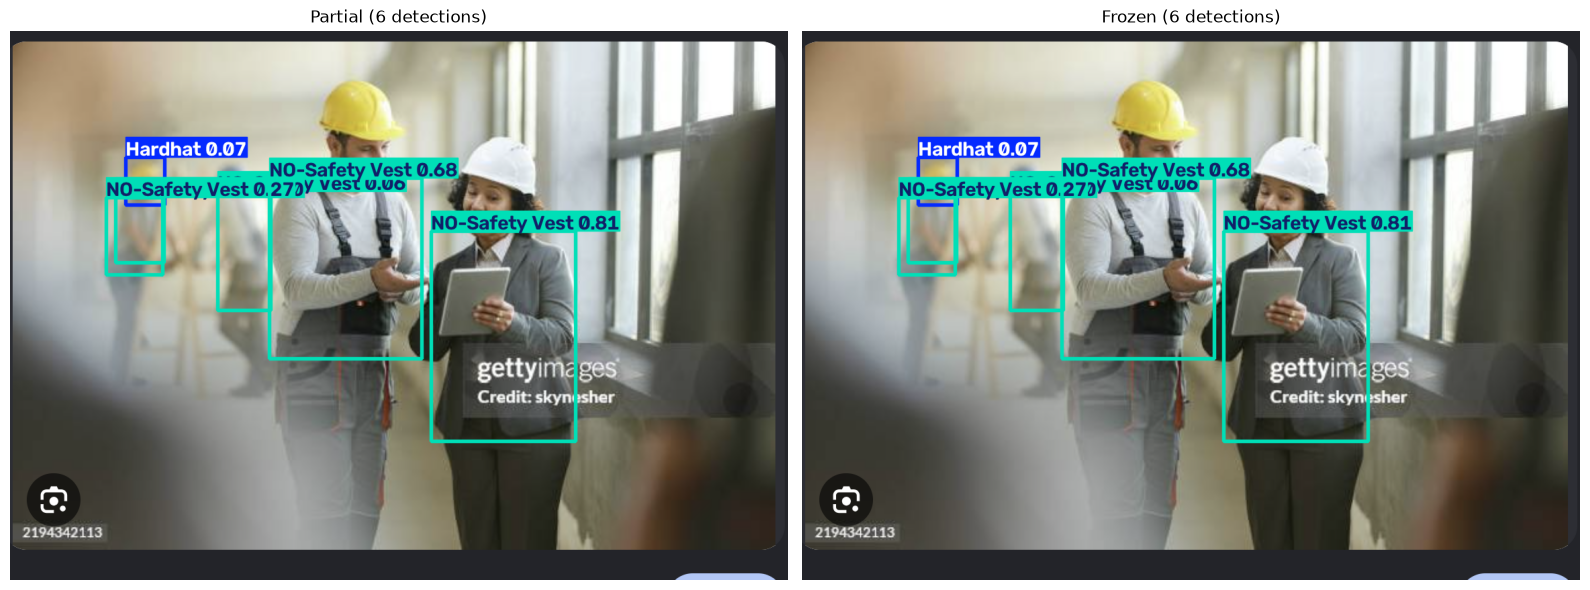

In [65]:
import matplotlib.pyplot as plt

frozen_path = Path.cwd() / "ppe_yolo11_best.pt"
assert frozen_path.is_file(), f"File not found: {frozen_path}"

frozen_model = YOLO(str(frozen_path))
print("Frozen model classes:", frozen_model.names)

picture = Path.cwd() / "far.jpeg"
assert picture.is_file(), f"Image not found: {picture}"

detectors = {
    "Partial": model,
    "Frozen": frozen_model,
}

fig, axes = plt.subplots(1, len(detectors), figsize=(8 * len(detectors), 8))

for ax, (name, detector) in zip(axes, detectors.items()):
    result = detector.predict(
        str(picture), conf=0.05, imgsz=640, verbose=False
    )[0]

    detections = [
        (detector.names[int(box.cls.item())], round(box.conf.item(), 3))
        for box in result.boxes
    ]
    print(name, ":", detections)

    # result.plot() returns a BGR image with boxes drawn; convert to RGB for matplotlib
    annotated = result.plot()[:, :, ::-1]
    ax.imshow(annotated)
    ax.set_title(f"{name} ({len(detections)} detections)")
    ax.axis("off")

plt.tight_layout()
plt.show()